# Validation: eht-imaging Reference Pipeline

This notebook uses **eht-imaging** (`ehtim`), the official EHT Collaboration imaging library,
to reproduce the core results of the Chael et al. (2018) closure-only imaging paper.

We compare three imaging methods on a synthetic M87*-like dataset:

| Method | Data terms | Gain-robust? |
|--------|-----------|-------------|
| **Visibility RML** | Complex visibilities | No |
| **Amp + Closure Phase** | Visibility amplitudes + closure phases | Partially |
| **Closure-only** | Closure phases + log closure amplitudes | **Yes** |

We also demonstrate that closure-only imaging is robust to station-based gain errors,
while visibility imaging degrades catastrophically.

In [1]:
import os, sys, warnings, io, tempfile
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

import ehtim
import ehtim.const_def as ehc

# Add task root to path for our generate_data module
TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TASK_DIR)

from src.generate_data import make_ring_image

%matplotlib inline
plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
print('ehtim loaded successfully')

Welcome to eht-imaging!

ehtim loaded successfully


## 1. Ground-Truth Image & EHT Array

We create an M87*-like crescent ring image and load the EHT 2017 array
with ECEF coordinates and SEFDs from the official `EHT2017.txt`.

In [2]:
# --- Ground truth image ---
N = 64
total_flux = 0.6  # Jy (typical M87* at 230 GHz)
pixel_size_uas = 2.0
psize = pixel_size_uas * ehc.RADPERUAS  # radians/pixel

gt = make_ring_image(N=N)
gt_jy = gt * total_flux  # Jy/pixel

# M87* coordinates
ra_hours = 12.513728717168174  # RA in fractional hours
dec_deg  = 12.39112323919932           # Dec in degrees

# # SgrA* coordinates
# ra_hours = 17.76112247222222  # RA in fractional hours
# dec_deg  = -28.99218944444445          # Dec in degrees

# ehtim Image object
im_gt = ehtim.image.Image(gt_jy, psize, ra_hours, dec_deg,
                          rf=230e9, source='M87', mjd=57849)
print(f'Image: {N}x{N}, pixel = {pixel_size_uas} uas, total flux = {im_gt.total_flux():.3f} Jy')

# --- EHT 2017 array (ECEF from eht-imaging EHT2017.txt) ---
arr_txt = """ALMA   2225061.164  -5440057.370  -2481681.150    90
APEX   2225039.530  -5441197.630  -2479303.360  3500
JCMT  -5464584.680  -2493001.170   2150653.980  6000
SMA   -5464523.400  -2493147.080   2150611.750  4900
SMT   -1828796.200  -5054406.800   3427865.200  5000
LMT    -768713.964  -5988541.798   2063275.947   600
PV     5088967.900   -301681.600   3825015.800  1400
SPT          0.010         0.010  -6359609.700  5000
"""
tmpf = tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False)
tmpf.write(arr_txt); tmpf.close()
eht = ehtim.array.load_txt(tmpf.name)
os.unlink(tmpf.name)

print(f'\nEHT 2017 Array: {len(eht.tarr)} stations')
print(f'{"Station":>8s} {"SEFD (Jy)":>10s}')
print('-' * 20)
for t in eht.tarr:
    print(f"{t['site']:>8s} {t['sefdr']:>10.0f}")

Image: 64x64, pixel = 2.0 uas, total flux = 0.600 Jy

EHT 2017 Array: 8 stations
 Station  SEFD (Jy)
--------------------
    ALMA         90
    APEX       3500
    JCMT       6000
     SMA       4900
     SMT       5000
     LMT        600
      PV       1400
     SPT       5000


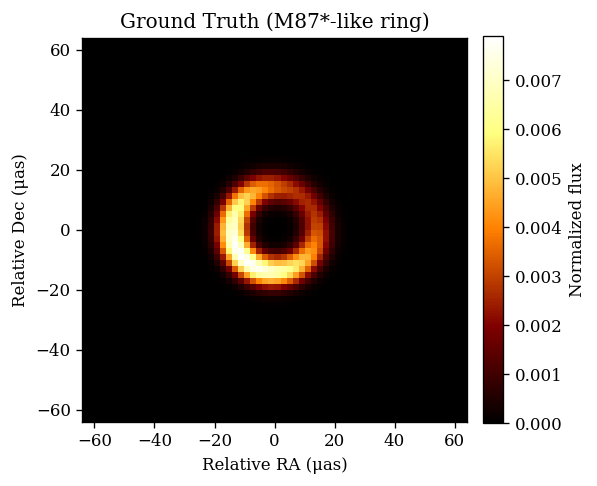

In [3]:
# Display ground truth
fov = N * pixel_size_uas
hw = fov / 2

fig, ax = plt.subplots(1, 1, figsize=(5, 4.5))
ax.imshow(gt, cmap='afmhot', origin='lower', extent=[-hw, hw, -hw, hw])
ax.set_xlabel('Relative RA (μas)')
ax.set_ylabel('Relative Dec (μas)')
ax.set_title('Ground Truth (M87*-like ring)')
plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04, label='Normalized flux')
plt.tight_layout()
plt.show()

## 2. Simulate EHT Observations

We use `ehtim` to generate two observation datasets:

1. **Calibrated**: perfect gain calibration (`ampcal=True, phasecal=True`)
2. **Corrupted**: station-based gain errors (`ampcal=False, phasecal=False, gainp=0.2`)

Both include realistic SEFD-based thermal noise.

In [4]:
# Observation parameters
tint  = 10     # integration time (seconds)
tadv  = 600    # scan cadence (seconds)
bw    = 2e9    # bandwidth (Hz)
tstart = 0.0   # start hour (UTC)
tstop  = 6.0   # stop hour (UTC)

# 1. Calibrated observation (perfect gains)
obs_cal = im_gt.observe(eht, tint=tint, tadv=tadv, tstart=tstart, tstop=tstop,
                        bw=bw, add_th_noise=True,
                        ampcal=True, phasecal=True,
                        ttype='direct', seed=42, verbose=False)
obs_cal = obs_cal.add_fractional_noise(0.01)  # 1% systematic noise floor

# 2. Gain-corrupted observation
obs_corrupt = im_gt.observe(eht, tint=tint, tadv=tadv, tstart=tstart, tstop=tstop,
                            bw=bw, add_th_noise=True,
                            ampcal=False, phasecal=False,
                            gainp=0.2,  # 20% gain amplitude error
                            ttype='direct', seed=42, verbose=False)
obs_corrupt = obs_corrupt.add_fractional_noise(0.01)

print(f'Calibrated obs:  {len(obs_cal.data)} visibilities')
print(f'Corrupted obs:   {len(obs_corrupt.data)} visibilities')
print(f'Resolution:      {obs_cal.res() / ehc.RADPERUAS:.1f} μas')

Calibrated obs:  421 visibilities
Corrupted obs:   421 visibilities
Resolution:      24.6 μas


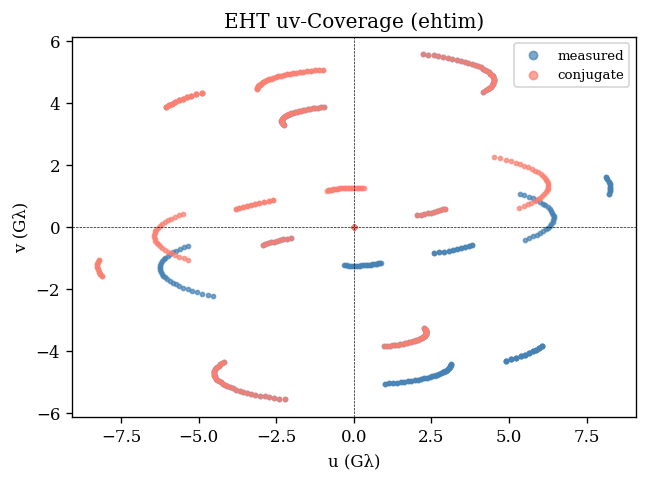

In [5]:
# Plot UV coverage
u_gl = obs_cal.data['u'] / 1e9
v_gl = obs_cal.data['v'] / 1e9

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(u_gl, v_gl, s=6, c='steelblue', alpha=0.7, label='measured')
ax.scatter(-u_gl, -v_gl, s=6, c='salmon', alpha=0.7, label='conjugate')
ax.set_xlabel('u (Gλ)')
ax.set_ylabel('v (Gλ)')
ax.set_title('EHT uv-Coverage (ehtim)')
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.4, ls='--')
ax.axvline(0, color='k', lw=0.4, ls='--')
ax.legend(fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

## 3. Closure Quantities: Gain Invariance

Closure phases and log closure amplitudes are invariant to station-based gains.
We verify this by comparing closure quantities from calibrated vs. corrupted data.

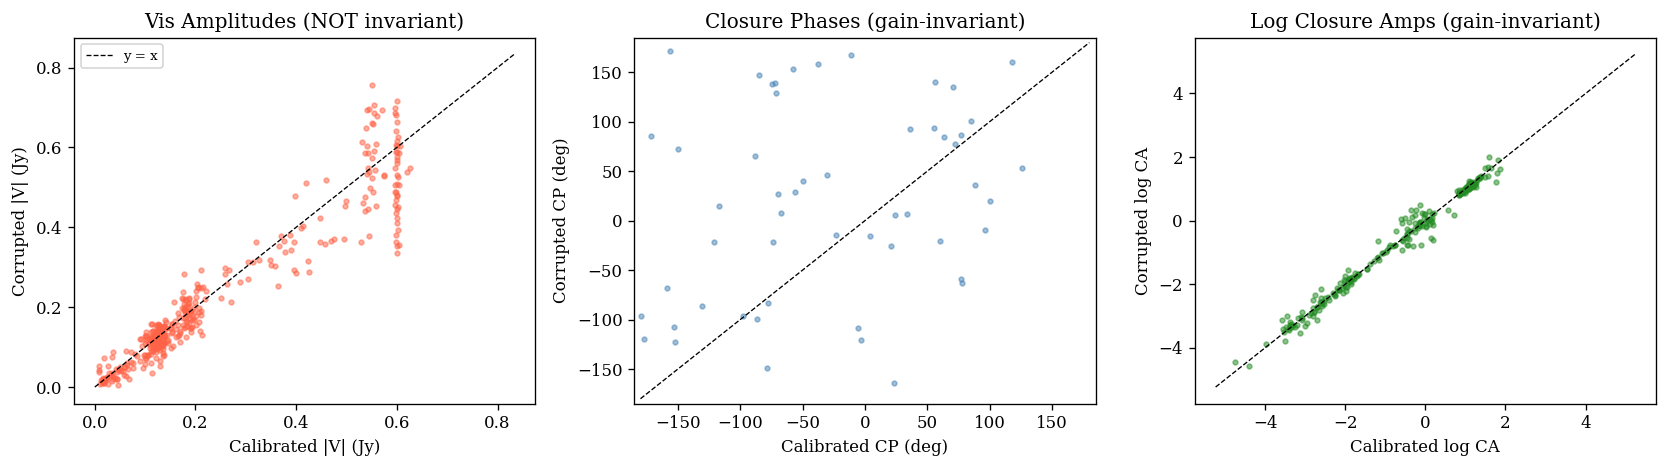

Matched 269 closure phases, 233 log closure amps
Vis amplitude RMSD:     0.0571 Jy  (large — gains corrupt amplitudes)
Closure phase RMSD:     1142.36 deg   (small — thermal noise only)
Log closure amp RMSD:   0.2057      (small — thermal noise only)


In [6]:
# Demonstrate gain invariance by computing closure quantities on the SAME baselines
# Use observe_same so both obs share identical uv-coverage
obs_corrupt_same = im_gt.observe_same(obs_cal,
                                      add_th_noise=True,
                                      ampcal=False, phasecal=False,
                                      gainp=0.2,
                                      ttype='direct', seed=42, verbose=False)

# Visibility amplitudes (NOT gain-invariant)
amp_cal = np.abs(obs_cal.data['vis'])
amp_cor = np.abs(obs_corrupt_same.data['vis'])

# Compute closure quantities — match by triangle/quadrangle identity
cp_cal = obs_cal.c_phases(mode='all', count='min', vtype='vis')
cp_cor = obs_corrupt_same.c_phases(mode='all', count='min', vtype='vis')
lca_cal = obs_cal.c_amplitudes(mode='all', count='min', vtype='vis', ctype='logcamp')
lca_cor = obs_corrupt_same.c_amplitudes(mode='all', count='min', vtype='vis', ctype='logcamp')

# Match closure phases by (time, t1, t2, t3) key
cp_cal_dict = {}
for row in cp_cal:
    key = (round(row['time'], 6), row['t1'], row['t2'], row['t3'])
    cp_cal_dict[key] = row['cphase']

cp_matched_cal, cp_matched_cor = [], []
for row in cp_cor:
    key = (round(row['time'], 6), row['t1'], row['t2'], row['t3'])
    if key in cp_cal_dict:
        cp_matched_cal.append(cp_cal_dict[key])
        cp_matched_cor.append(row['cphase'])

cp_matched_cal = np.array(cp_matched_cal)
cp_matched_cor = np.array(cp_matched_cor)

# Match log closure amps by (time, t1, t2, t3, t4) key
lca_cal_dict = {}
for row in lca_cal:
    key = (round(row['time'], 6), row['t1'], row['t2'], row['t3'], row['t4'])
    lca_cal_dict[key] = row['camp']

lca_matched_cal, lca_matched_cor = [], []
for row in lca_cor:
    key = (round(row['time'], 6), row['t1'], row['t2'], row['t3'], row['t4'])
    if key in lca_cal_dict:
        lca_matched_cal.append(lca_cal_dict[key])
        lca_matched_cor.append(row['camp'])

lca_matched_cal = np.array(lca_matched_cal)
lca_matched_cor = np.array(lca_matched_cor)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Vis amplitudes
ax = axes[0]
ax.scatter(amp_cal, amp_cor, s=8, alpha=0.5, c='tomato')
lim = max(amp_cal.max(), amp_cor.max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='y = x')
ax.set_xlabel('Calibrated |V| (Jy)')
ax.set_ylabel('Corrupted |V| (Jy)')
ax.set_title('Vis Amplitudes (NOT invariant)')
ax.legend(fontsize=8)

# Closure phases
ax = axes[1]
ax.scatter(cp_matched_cal, cp_matched_cor, s=8, alpha=0.5, c='steelblue')
ax.plot([-180, 180], [-180, 180], 'k--', lw=0.8)
ax.set_xlabel('Calibrated CP (deg)')
ax.set_ylabel('Corrupted CP (deg)')
ax.set_title('Closure Phases (gain-invariant)')
ax.set_xlim(-185, 185); ax.set_ylim(-185, 185)

# Log closure amplitudes
ax = axes[2]
lim_lca = max(np.abs(lca_matched_cal).max(), np.abs(lca_matched_cor).max()) * 1.1
ax.scatter(lca_matched_cal, lca_matched_cor, s=8, alpha=0.5, c='forestgreen')
ax.plot([-lim_lca, lim_lca], [-lim_lca, lim_lca], 'k--', lw=0.8)
ax.set_xlabel('Calibrated log CA')
ax.set_ylabel('Corrupted log CA')
ax.set_title('Log Closure Amps (gain-invariant)')

plt.tight_layout()
plt.show()

# Quantify
amp_rmsd = np.sqrt(np.mean((amp_cal - amp_cor)**2))
cp_rmsd = np.sqrt(np.mean((cp_matched_cal - cp_matched_cor)**2))
lca_rmsd = np.sqrt(np.mean((lca_matched_cal - lca_matched_cor)**2))
print(f'Matched {len(cp_matched_cal)} closure phases, {len(lca_matched_cal)} log closure amps')
print(f'Vis amplitude RMSD:     {amp_rmsd:.4f} Jy  (large — gains corrupt amplitudes)')
print(f'Closure phase RMSD:     {cp_rmsd:.2f} deg   (small — thermal noise only)')
print(f'Log closure amp RMSD:   {lca_rmsd:.4f}      (small — thermal noise only)')

## 4. Image Reconstruction (Calibrated Data)

We reconstruct using three data terms on **calibrated** data (perfect gains):

1. **Vis RML**: Complex visibilities  (`data_term = {'vis': 100}`)
2. **Amp + CPhase**: Amplitudes + closure phases  (`{'amp': 100, 'cphase': 50}`)
3. **Closure-only**: Closure phases + log closure amps  (`{'cphase': 50, 'logcamp': 50}`)

All use Maximum Entropy (`gs`) + quadratic (`simple`) regularizers.

In [7]:
# Gaussian prior / initial image
im0 = ehtim.image.make_empty(N, im_gt.fovx(), ra_hours, dec_deg,
                             rf=230e9, source='M87')
im0 = im0.add_gauss(total_flux,
                     (20 * ehc.RADPERUAS, 20 * ehc.RADPERUAS, 0, 0, 0))

# Suppress ehtim verbose output
old_stdout = sys.stdout

def run_ehtim_imaging(obs, data_term, reg_term, label, niter=3, maxit=300):
    """Run ehtim RML imaging with given data/regularizer terms."""
    global old_stdout
    imgr = ehtim.imager.Imager(obs, im0, prior_im=im0, flux=total_flux,
                               data_term=data_term, reg_term=reg_term,
                               maxit=maxit, ttype='direct')
    sys.stdout = io.StringIO()
    out = imgr.make_image_I(niter=niter, blur_frac=0, show_updates=False)
    sys.stdout = old_stdout
    return out

# Common regularizer
reg = {'gs': 1, 'simple': 10}

print('Reconstructing on CALIBRATED data...')
print('  [1/3] Vis RML ...')
out_vis_cal = run_ehtim_imaging(obs_cal,
    data_term={'vis': 100}, reg_term=reg, label='Vis')

print('  [2/3] Amp + CPhase ...')
out_amp_cal = run_ehtim_imaging(obs_cal,
    data_term={'amp': 100, 'cphase': 50}, reg_term=reg, label='Amp+CP')

print('  [3/3] Closure-only ...')
out_clo_cal = run_ehtim_imaging(obs_cal,
    data_term={'cphase': 50, 'logcamp': 50}, reg_term=reg, label='Closure')

print('Done!')

Reconstructing on CALIBRATED data...
  [1/3] Vis RML ...
Initializing imager data products . . .


  [2/3] Amp + CPhase ...
Initializing imager data products . . .


  [3/3] Closure-only ...
Initializing imager data products . . .


Done!


In [8]:
def compute_metrics(est, ref):
    """Compute NRMSE and NCC after flux-normalizing the estimate."""
    est_n = est * (ref.sum() / (est.sum() + 1e-30))
    nrmse = float(np.sqrt(np.mean((est_n - ref)**2))
                  / (np.sqrt(np.mean(ref**2)) + 1e-30))
    ncc = float(np.sum(est_n * ref)
               / (np.sqrt(np.sum(est_n**2)) * np.sqrt(np.sum(ref**2)) + 1e-30))
    return {'nrmse': nrmse, 'ncc': ncc}

# Collect results
cal_results = {
    'Vis RML':      out_vis_cal.imarr(),
    'Amp + CPhase': out_amp_cal.imarr(),
    'Closure-only': out_clo_cal.imarr(),
}

cal_metrics = {name: compute_metrics(img, gt) for name, img in cal_results.items()}

# Print metrics table
print(f'{"Method":<20s} {"NRMSE":>8s} {"NCC":>8s}')
print('-' * 38)
for name, m in cal_metrics.items():
    print(f'{name:<20s} {m["nrmse"]:>8.4f} {m["ncc"]:>8.4f}')

Method                  NRMSE      NCC
--------------------------------------
Vis RML                0.2517   0.9705
Amp + CPhase           0.6342   0.8044
Closure-only           0.8927   0.7150


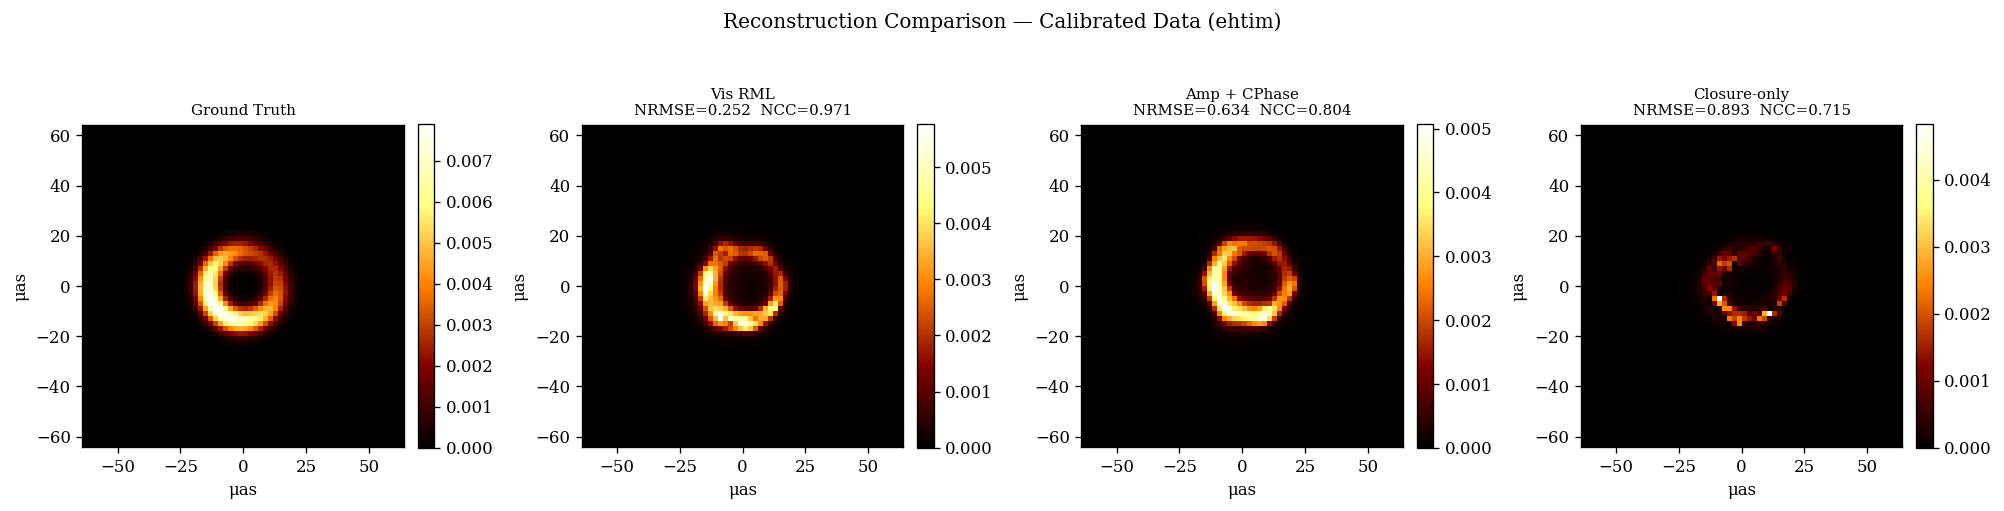

In [9]:
# Visual comparison — calibrated data (Figure 4 equivalent)
panels = [('Ground Truth', gt)] + [(n, img) for n, img in cal_results.items()]
n_panels = len(panels)

fig, axes = plt.subplots(1, n_panels, figsize=(4.2 * n_panels, 4.2))
for ax, (title, img) in zip(axes, panels):
    im_show = ax.imshow(img, cmap='afmhot', origin='lower',
                        extent=[-hw, hw, -hw, hw], vmin=0, vmax=img.max())
    if title != 'Ground Truth':
        m = cal_metrics[title]
        title = f'{title}\nNRMSE={m["nrmse"]:.3f}  NCC={m["ncc"]:.3f}'
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('μas')
    ax.set_ylabel('μas')
    plt.colorbar(im_show, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Reconstruction Comparison — Calibrated Data (ehtim)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Gain Robustness Test

Now we repeat imaging on the **gain-corrupted** data.

- Visibility imaging should **degrade** because gains corrupt complex visibilities.
- Closure-only imaging should remain **robust** because closure quantities are gain-invariant.

In [10]:
print('Reconstructing on GAIN-CORRUPTED data...')
print('  [1/3] Vis RML ...')
out_vis_cor = run_ehtim_imaging(obs_corrupt,
    data_term={'vis': 100}, reg_term=reg, label='Vis')

print('  [2/3] Amp + CPhase ...')
out_amp_cor = run_ehtim_imaging(obs_corrupt,
    data_term={'amp': 100, 'cphase': 50}, reg_term=reg, label='Amp+CP')

print('  [3/3] Closure-only ...')
out_clo_cor = run_ehtim_imaging(obs_corrupt,
    data_term={'cphase': 50, 'logcamp': 50}, reg_term=reg, label='Closure')

print('Done!')

Reconstructing on GAIN-CORRUPTED data...
  [1/3] Vis RML ...
Warning! Specified flux is < 80% of maximum visibility amplitude!
Initializing imager data products . . .


  [2/3] Amp + CPhase ...
Warning! Specified flux is < 80% of maximum visibility amplitude!
Initializing imager data products . . .


  [3/3] Closure-only ...
Warning! Specified flux is < 80% of maximum visibility amplitude!
Initializing imager data products . . .


Done!


In [11]:
cor_results = {
    'Vis RML':      out_vis_cor.imarr(),
    'Amp + CPhase': out_amp_cor.imarr(),
    'Closure-only': out_clo_cor.imarr(),
}
cor_metrics = {name: compute_metrics(img, gt) for name, img in cor_results.items()}

print(f'{"Method":<20s} {"Calibrated":>18s} {"Corrupted":>18s}')
print(f'{"":20s} {"NRMSE":>8s} {"NCC":>8s}   {"NRMSE":>8s} {"NCC":>8s}')
print('-' * 58)
for name in cal_metrics:
    mc = cal_metrics[name]
    mg = cor_metrics[name]
    print(f'{name:<20s} {mc["nrmse"]:>8.4f} {mc["ncc"]:>8.4f}   {mg["nrmse"]:>8.4f} {mg["ncc"]:>8.4f}')

Method                       Calibrated          Corrupted
                        NRMSE      NCC      NRMSE      NCC
----------------------------------------------------------
Vis RML                0.2517   0.9705     3.7344   0.0019
Amp + CPhase           0.6342   0.8044     1.7644   0.4164
Closure-only           0.8927   0.7150     0.6756   0.8069


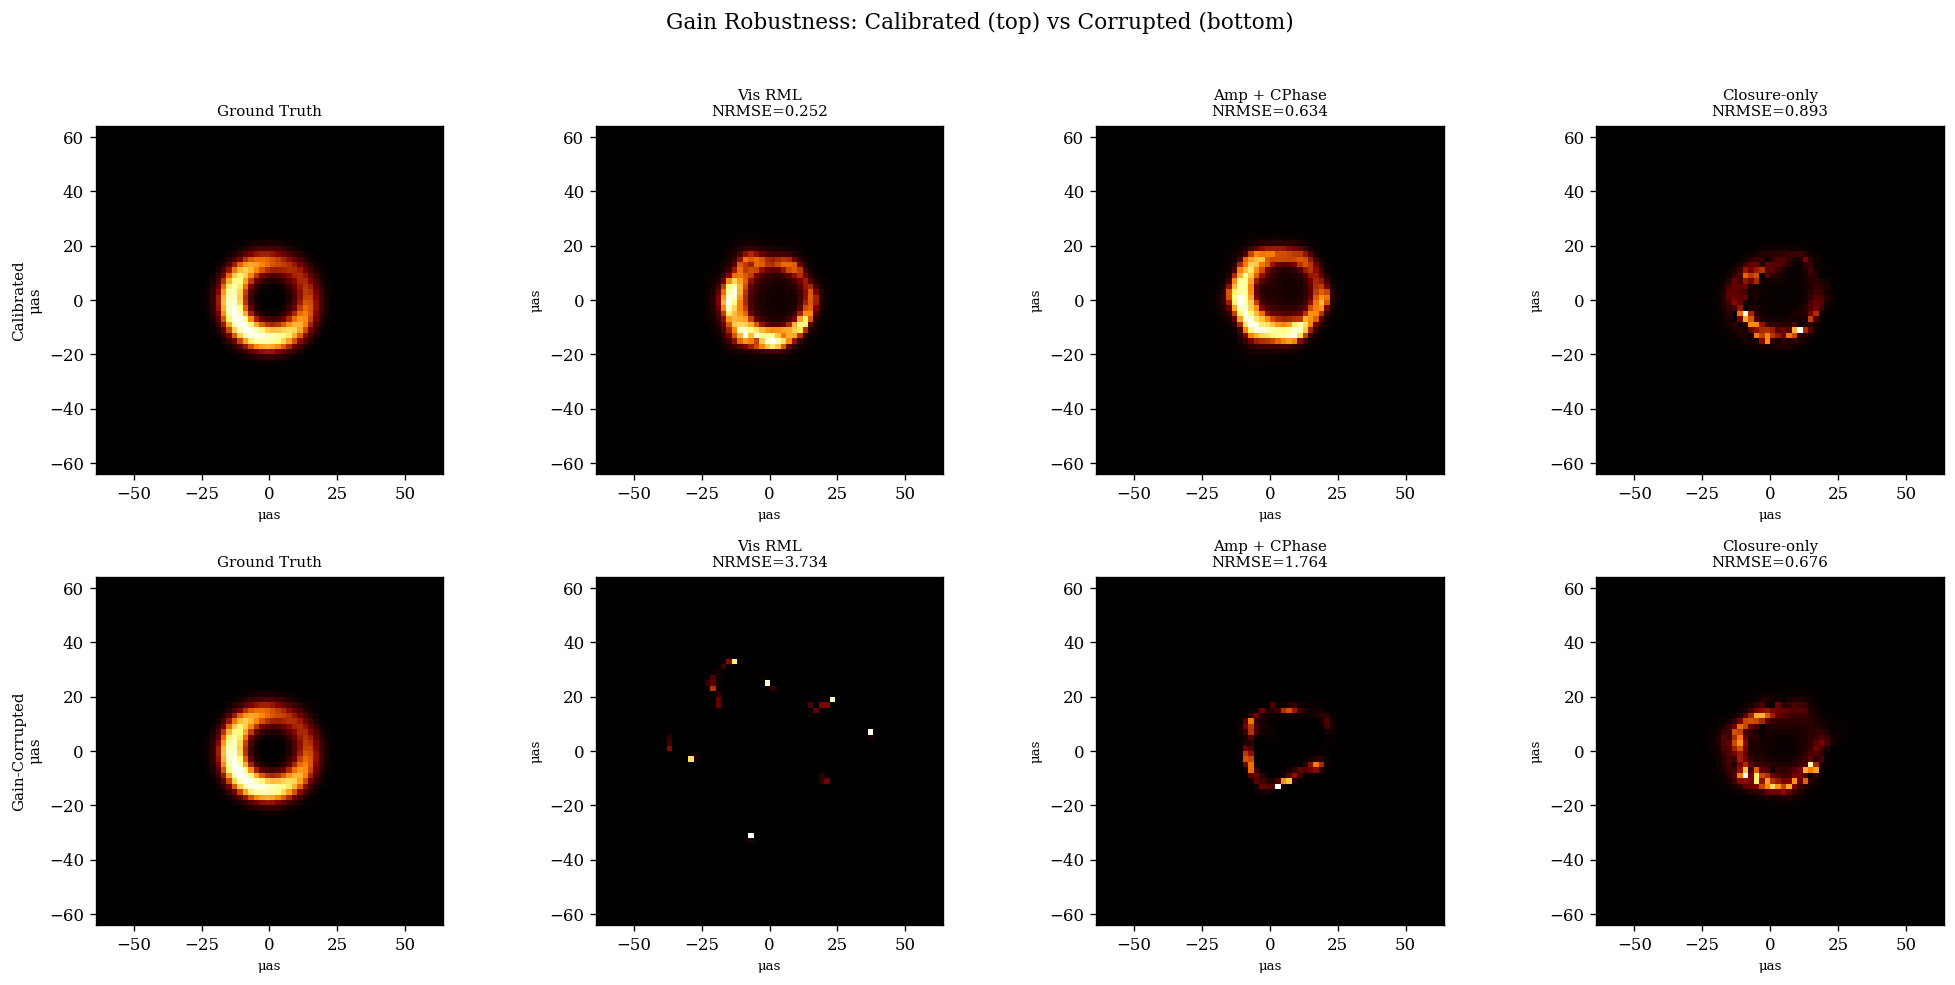

In [12]:
# Side-by-side: calibrated vs corrupted for each method
methods = ['Vis RML', 'Amp + CPhase', 'Closure-only']

fig, axes = plt.subplots(2, 4, figsize=(17, 8))

# Row 0: calibrated
axes[0, 0].imshow(gt, cmap='afmhot', origin='lower', extent=[-hw, hw, -hw, hw])
axes[0, 0].set_title('Ground Truth', fontsize=9)
for j, name in enumerate(methods):
    m = cal_metrics[name]
    img = cal_results[name]
    axes[0, j+1].imshow(img, cmap='afmhot', origin='lower',
                        extent=[-hw, hw, -hw, hw], vmin=0, vmax=img.max())
    axes[0, j+1].set_title(f'{name}\nNRMSE={m["nrmse"]:.3f}', fontsize=9)

# Row 1: corrupted
axes[1, 0].imshow(gt, cmap='afmhot', origin='lower', extent=[-hw, hw, -hw, hw])
axes[1, 0].set_title('Ground Truth', fontsize=9)
for j, name in enumerate(methods):
    m = cor_metrics[name]
    img = cor_results[name]
    axes[1, j+1].imshow(img, cmap='afmhot', origin='lower',
                        extent=[-hw, hw, -hw, hw], vmin=0, vmax=img.max())
    axes[1, j+1].set_title(f'{name}\nNRMSE={m["nrmse"]:.3f}', fontsize=9)

for ax in axes.flat:
    ax.set_xlabel('μas', fontsize=8)
    ax.set_ylabel('μas', fontsize=8)

axes[0, 0].set_ylabel('Calibrated\nμas', fontsize=9)
axes[1, 0].set_ylabel('Gain-Corrupted\nμas', fontsize=9)

fig.suptitle('Gain Robustness: Calibrated (top) vs Corrupted (bottom)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()